### Import Libraries

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os
import joblib
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline

### Load Dataset

In [28]:
df = pd.read_csv("../data/processed/ridewise_cus_seg.csv")

In [29]:
df.head()

,age,gender,cancelled_trips,days_since_last_trip,churned,signup_channel,income_level,age_band,total_cancelled_trips,net_platform_revenue,...,promo_intensity_q,signup_month,last_trip_month,is_inactive_20d,is_inactive_30d,recency_bucket,is_high_value,high_value_and_inactive,low_engagement_and_recent,usage_intensity_score
0,19,Other,7,20,0,Ads,high,18–24,4,255.51,...,High,2023-04,2025-08,1,0,Mid-Inactive,1,1,0,0.794104
1,26,Other,0,44,0,Referral,medium,25–34,6,150.44,...,High,2023-01,2025-07,1,1,Inactive,0,0,0,0.585601
2,45,Male,1,4,0,Referral,medium,45–54,3,82.09,...,Low,2024-07,2026-11,0,0,Recent,0,0,1,0.326644
3,32,Other,3,7,0,Ads,medium,25–34,2,184.16,...,Mid-Low,2025-03,2027-09,0,0,Recent,1,0,1,0.359297
4,44,Male,2,33,0,Organic,medium,35–44,4,53.25,...,Mid-Low,2024-04,2026-09,1,1,Inactive,0,0,0,0.550680


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        3000 non-null   int64  
 1   gender                     3000 non-null   object 
 2   cancelled_trips            3000 non-null   int64  
 3   days_since_last_trip       3000 non-null   int64  
 4   churned                    3000 non-null   int64  
 5   signup_channel             3000 non-null   object 
 6   income_level               3000 non-null   object 
 7   age_band                   3000 non-null   object 
 8   total_cancelled_trips      3000 non-null   int64  
 9   net_platform_revenue       3000 non-null   float64
 10  avg_duration_min           3000 non-null   float64
 11  promo_used_avg             3000 non-null   float64
 12  total_promo_cost           3000 non-null   float64
 13  avg_discount_value         3000 non-null   float

In [31]:
df.duplicated().sum()

0

In [32]:
df.isna().sum()

age                          0
gender                       0
cancelled_trips              0
days_since_last_trip         0
churned                      0
signup_channel               0
income_level                 0
age_band                     0
total_cancelled_trips        0
net_platform_revenue         0
avg_duration_min             0
promo_used_avg               0
total_promo_cost             0
avg_discount_value           0
avg_driver_burden            0
driver_borne_total           0
driver_burden_ratio          0
promo_used_rate              0
promo_dependency             0
revenue_quartile             0
promo_intensity_q            0
signup_month                 0
last_trip_month              0
is_inactive_20d              0
is_inactive_30d              0
recency_bucket               0
is_high_value                0
high_value_and_inactive      0
low_engagement_and_recent    0
usage_intensity_score        0
dtype: int64

<Axes: >

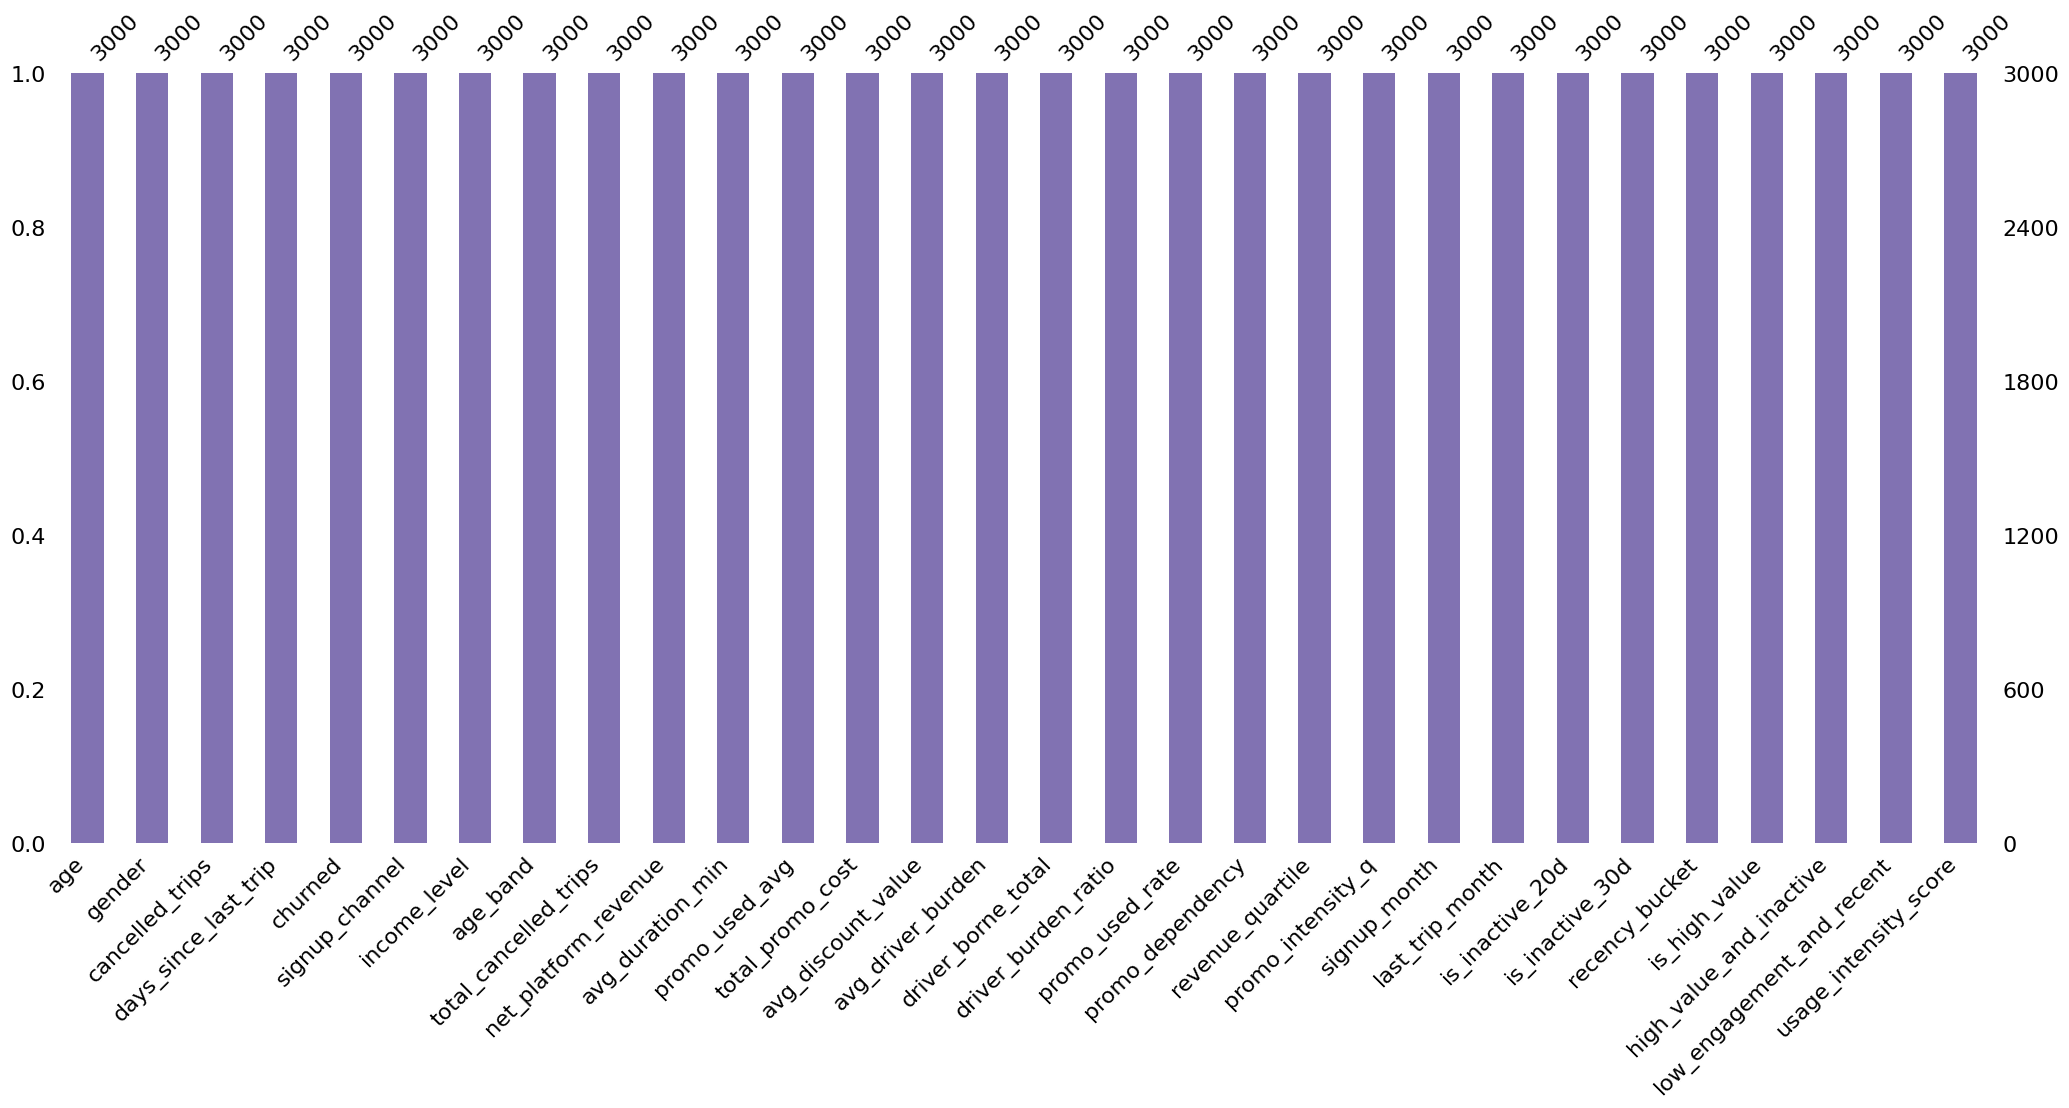

In [33]:
msno.bar(df, color="#8172B2")

### Customer Segmentation - Unsupervised Learning

In [34]:
# Define segmentation features

seg_features = ["usage_intensity_score", "low_engagement_and_recent", "net_platform_revenue", "is_high_value", 
                "high_value_and_inactive", "days_since_last_trip", "is_inactive_20d", "is_inactive_30d", 
                "promo_used_rate", "promo_used_avg", "total_promo_cost", "avg_discount_value", "promo_dependency", 
                "avg_duration_min", "total_cancelled_trips", "avg_driver_burden", "driver_borne_total", "driver_burden_ratio"]

# Dataset for segmentation
df_seg = df[seg_features].copy()
df_seg.shape

(3000, 18)

In [35]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_seg)

# Sanity Check
pd.DataFrame(X_scaled, columns=seg_features).describe()

,usage_intensity_score,low_engagement_and_recent,net_platform_revenue,is_high_value,high_value_and_inactive,days_since_last_trip,is_inactive_20d,is_inactive_30d,promo_used_rate,promo_used_avg,total_promo_cost,avg_discount_value,promo_dependency,avg_duration_min,total_cancelled_trips,avg_driver_burden,driver_borne_total,driver_burden_ratio
count,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03
mean,-1.290819e-16,5.802766e-17,-1.397401e-16,-2.368476e-17,1.184238e-17,2.250052e-17,-3.315866e-17,4.381680e-17,1.959914e-16,-1.113184e-16,4.618528e-17,-6.394885e-16,4.736952e-18,2.025047e-16,-9.473903e-18,8.585725e-17,8.289665e-18,-1.065814e-17
std,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00,1.000167e+00
min,-2.497592e+00,-9.933554e-01,-2.010445e+00,-5.773503e-01,-3.308587e-01,-9.745810e-01,-8.164966e-01,-5.829956e-01,-1.930457e+00,-2.471125e+00,-1.534688e+00,-3.098063e+00,-9.940179e-01,-6.135045e+00,-1.850571e+00,-2.611747e+00,-1.022151e+00,-8.123734e-01
25%,-7.761379e-01,-9.933554e-01,-7.065164e-01,-5.773503e-01,-3.308587e-01,-6.992843e-01,-8.164966e-01,-5.829956e-01,-7.215283e-01,-6.188191e-01,-7.592312e-01,-4.405828e-01,-9.940179e-01,-6.398021e-01,-7.731264e-01,-6.517101e-01,-8.931753e-01,-7.281899e-01
50%,-1.416048e-02,-9.933554e-01,-2.461720e-01,-5.773503e-01,-3.308587e-01,-2.863392e-01,-8.164966e-01,-5.829956e-01,-6.525274e-02,-4.313094e-02,-1.339995e-01,8.962986e-02,-9.940179e-01,-9.817829e-03,-5.482996e-02,-4.515997e-02,-2.571400e-01,-3.209930e-01
75%,7.797654e-01,1.006689e+00,5.182088e-01,0.000000e+00,-3.308587e-01,4.019026e-01,1.224745e+00,1.715279e+00,6.296273e-01,5.998030e-01,5.991288e-01,5.999500e-01,1.006018e+00,6.296723e-01,6.634665e-01,5.845992e-01,5.933637e-01,3.161040e-01
max,2.914840e+00,1.006689e+00,4.082572e+00,1.732051e+00,3.022439e+00,6.687845e+00,1.224745e+00,1.715279e+00,4.469754e+00,1.419962e+01,5.102881e+00,2.476024e+00,1.006018e+00,4.534288e+00,4.254949e+00,5.118582e+00,3.343866e+00,6.590380e+00


### Choose Number of Clusters using:
- Elbow method (inertia)
- Silhouette score (cluster separation)

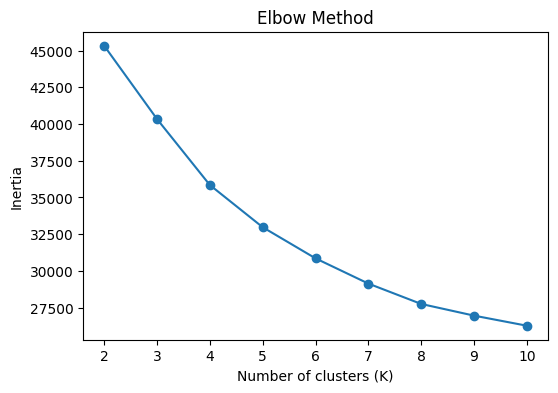

In [36]:
# Elbow Method
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [37]:
# silhouette_score
sil_scores = {}

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

sil_scores

{2: 0.1772822005832243,
 3: 0.19132681785000188,
 4: 0.1682931077396479,
 5: 0.17135898018408352,
 6: 0.1794404581648396,
 7: 0.17482858672399754}

### Observation of Findings
The elbow method indicated diminishing returns beyond 5 clusters.
Although silhouette scores were modest across K, this is expected in real-world behavioral data.
K = 5 provided the best balance between structural separation and business interpretability.”

In [38]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["segment"] = kmeans.fit_predict(X_scaled)

In [39]:
# Segment Profiling
df["segment"].value_counts().sort_index()

segment
0    626
1    435
2    811
3    296
4    832
Name: count, dtype: int64

### Observation of Findings
The distribution of customers across the five clusters indicates a balanced and structurally sound segmentation.

- Segment 2 (27.0%) and Segment 4 (27.7%) are the largest groups, representing the dominant behavioral patterns in the customer base.
- Segment 0 (20.9%) and Segment 1 (14.5%) form mid-sized groups, suggesting meaningful but more specialized customer behaviors.

- Segment 3 (9.9%) is the smallest cluster, but still large enough to be statistically and operationally relevant.

In [40]:
#Profile numeric features by segment
segment_profile = (df.groupby("segment")[seg_features]
                   .mean().round(2))

segment_profile

,usage_intensity_score,low_engagement_and_recent,net_platform_revenue,is_high_value,high_value_and_inactive,days_since_last_trip,is_inactive_20d,is_inactive_30d,promo_used_rate,promo_used_avg,total_promo_cost,avg_discount_value,promo_dependency,avg_duration_min,total_cancelled_trips,avg_driver_burden,driver_borne_total,driver_burden_ratio
segment,,,,,,,,,,,,,,,,,,
0,0.44,0.00,105.85,0.00,0.0,48.56,1.00,0.92,0.08,0.15,42.36,15.96,0.42,24.96,4.54,3.14,3.35,0.09
1,0.56,0.82,233.89,0.99,0.0,8.35,0.00,0.00,0.09,0.15,77.82,17.66,0.54,25.02,6.77,3.63,3.69,0.05
2,0.42,0.70,107.34,0.03,0.0,10.15,0.15,0.00,0.05,0.11,24.98,15.33,0.02,25.09,4.57,3.03,3.43,0.12
3,0.56,0.00,231.95,1.00,1.0,41.75,1.00,0.61,0.09,0.15,74.56,17.39,0.50,25.01,6.81,3.44,3.84,0.06
4,0.42,0.68,109.39,0.00,0.0,10.94,0.18,0.00,0.13,0.19,66.46,17.47,0.99,25.11,4.75,3.48,3.34,0.05


### Observation of Findings
**Segment 0 - Inactive, Low-Value Users (~21% of customers)**

Given low usage intensity (0.44), very high inactivity (is_inactive_20d = 1.00, is_inactive_30d = 0.92), long recency gap (≈ 49 days since last trip), low net platform revenue (~106) and low promotional usage and cost, this segment represents disengaged and low-value customers who have largely stopped using the platform. They are not promotion-driven; rather, they appear to have organically churned or are in late-stage inactivity.

**Business implication:**
- Low ROI for aggressive retention
- Suitable for reactivation experiments or deprioritization
- Useful as a baseline churn-prone group

**Segment 1 - High-Value, Recently Active Customers (~15% of customers)**

With key characteristics as high usage intensity (0.56), Very recent activity (≈ 8 days since last trip), almost entirely high-value users (is_high_value ≈ 0.99), high net platform revenue (~234) and moderate promo usage and cost, this segment represent the core revenue-driving segment. Customers are active, valuable, and engaged. Promotions are used, but not excessively, suggesting healthy organic demand.

**Business implication:**
- Protect at all costs
- Focus on loyalty programs and experience optimization
- Avoid over-discounting

**Segment 2 - Low Engagement, Moderate-Value Users (~27% of customers)**

This group uses the platform occasionally but without strong attachment. They are not price-sensitive, nor deeply engaged and exhibit low usage intensity (0.42), moderate recency (≈ 10 days), not high-value (is_high_value ≈ 0.03), moderate revenue (~107) and low promo dependency (promo_dependency ≈ 0.02).

**Business implication:**
- High potential for engagement uplift
- Ideal for nudges, reminders, and product education
- Less responsive to heavy promotions

**Segment 3 - High-Value but Inactive Customers (~10% of customers)**

This is a classic high-risk, high-impact churn group and the most strategically critical segment. These customers were once valuable but have become inactive with high usage intensity historically (0.56), long inactivity (≈ 42 days), entirely high-value (is_high_value = 1.00), high net revenue (~232), high cancellation counts and moderate promo dependency.

**Business implication:**
- Top priority for churn prevention
- Personalized reactivation campaigns
- Service recovery and trust rebuilding

**Segment 4 - Promo-Dependent Active Users (~28% of customers)**

This segment is highly promotion-driven with moderate usage intensity (0.42), recent activity (≈ 11 days), low inherent value (is_high_value = 0.00), high promo dependency (~0.99), high promo cost and discount usage. Engagement is sustained primarily through incentives, making profitability fragile.

**Business implication:**
- Tight control of promotional spend
- Experiment with non-monetary incentives
- Gradual reduction of discount reliance


### Cross-Segment Insights

- Revenue concentration is driven primarily by Segments 1 and 3

- Churn risk is highest in Segments 0 and 3, but with very different business value

- Promotion strategy should be segment-specific, not global

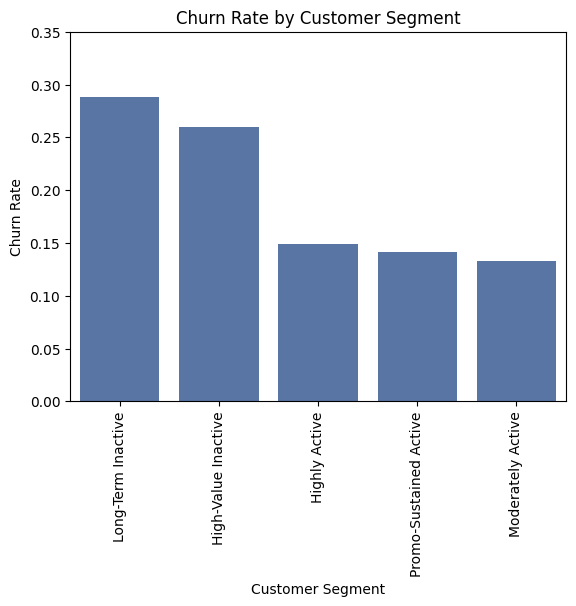

segment
0    0.288
3    0.260
1    0.149
4    0.141
2    0.133
Name: churned, dtype: float64

In [41]:
# Add churn rate per segment
seg_churned = df.groupby("segment")["churned"].mean().round(3).sort_values(ascending=False)

seg_churned_rate = (seg_churned.reset_index().rename(columns={"churned": "churn_rate"}))

segment_labels = {
    0: "Long-Term Inactive",
    1: "Highly Active",
    2: "Moderately Active",
    3: "High-Value Inactive",
    4: "Promo-Sustained Active"
}

seg_churned_rate["segment_name"] = seg_churned_rate["segment"].map(segment_labels)


color='#4C72B0'

sns.barplot(data=seg_churned_rate, 
            x="segment_name", 
            y="churn_rate", 
            order=seg_churned_rate["segment_name"], 
            color="#4C72B0")

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate")
plt.ylim(0, 0.35)
plt.xticks(rotation=90)
plt.show()


seg_churned

### Observation of Findings

**Segment 0** shows highest churn risk with churn rate of 28.8% representing customers who are largely disengaged and nearing permanent churn. High churn is expected and structurally consistent with their behavioral profile. Ridewise should avoid heavy retention spend and deprioritize or reactivate low-cost.

**Segment 3** shows high-value churn risk with churn rate of 26%. This is the most strategically dangerous segment because although it represents smaller customer group than Segment 0, churn here results in significant revenue loss. Ridewise should give this segment highest priority for personalized retention, service recovery, trust rebuilding, and targeted incentives.

**Segment 1** shows stable, high-value customers with churn rate of 14.9%. Despite their value, churn is meaningfully lower than inactive segments, indicating strong customer-product fit. Ridewise should maintain loyalty and focus on experience, not discounts.

**Segment 2** shows low engagement but retainable with churn rate of 13.3% with latent stability despite lower engagement. They are not actively churning but are not strongly attached. Ridewise should promote engagement nudges, product education and habit formation.

**Segment 4** shows promo-dependent but Retained with churn rate of 14.1%. In this segment, churn is relatively controlled but artificially suppressed by promotions. Profitability risk exists even if churn risk is moderate. Ridewise should engage in gradual reduction of discount intensity and test non-monetary engagement strategies.

**Overall:**
Churn is not evenly distributed across customers

High churn appears in: 

- Low-value inactive users (Segment 0)
- High-value inactive users (Segment 3)

In [42]:
# Profile categorical features

# Signup Channel Distribution
pd.crosstab(df["segment"], df["signup_channel"], normalize="index")

signup_channel,Ads,Organic,Partnership,Referral
segment,,,,
0,0.258786,0.263578,0.249201,0.228435
1,0.308046,0.257471,0.234483,0.200000
2,0.237978,0.226880,0.300863,0.234279
3,0.229730,0.233108,0.266892,0.270270
4,0.259615,0.254808,0.252404,0.233173


### Observation of Findings

Customer behavior post-signup is not primarily determined by acquisition channel. This suggests that in-app experience and lifecycle engagement matter more than how users were acquired.

Implication:

- Segment-specific strategies should focus on post-acquisition engagement, not acquisition source
- No need for channel-specific segmentation

In [43]:
# Income Level Distribution

pd.crosstab(df["segment"], df["income_level"], normalize="index")


income_level,high,low,medium
segment,,,
0,0.073482,0.258786,0.667732
1,0.639080,0.009195,0.351724
2,0.076449,0.278668,0.644883
3,0.682432,0.013514,0.304054
4,0.060096,0.293269,0.646635


### Observation of Findings

Value-based segmentation is economically meaningful.
- Segments 1 and 3 are overwhelmingly high-income
- Segments 0, 2, and 4 are dominated by medium- and low-income users

Implication:

- Retention spend on high-income segments yields higher ROI
- Promo-heavy strategies in lower-income segments should be carefully controlled

In [44]:
# Gender Distribution

pd.crosstab(df["segment"], df["gender"], normalize="index")

gender,Female,Male,Other
segment,,,
0,0.332268,0.354633,0.313099
1,0.335632,0.314943,0.349425
2,0.339088,0.318126,0.342787
3,0.442568,0.277027,0.280405
4,0.320913,0.336538,0.342548


### Observation of Findings

Gender distribution is balanced across most segments with segment 3 showing a slightly higher Female proportion, but differences are modest. This signifies that gender is not a primary driver of behavioral segmentation.

Implication:

- No need for gender-specific segmentation or targeting

In [45]:
# Revenue Quartile Alignment (Very Important)

pd.crosstab(df["segment"], df["revenue_quartile"], normalize="index")

revenue_quartile,High,Low,Mid-High,Mid-Low
segment,,,,
0,0.000000,0.338658,0.329073,0.332268
1,0.988506,0.000000,0.009195,0.002299
2,0.028360,0.340321,0.294698,0.336621
3,1.000000,0.000000,0.000000,0.000000
4,0.001202,0.314904,0.361779,0.322115


### Observation of Findings

This is the strongest categorical validation of your segmentation. 
 - Segment 1 shows ~99% in High revenue quartile
 - Segment 3 shows 100% in High revenue quartile
 - Segments 0, 2, 4 shows Predominantly Mid-Low / Low quartiles

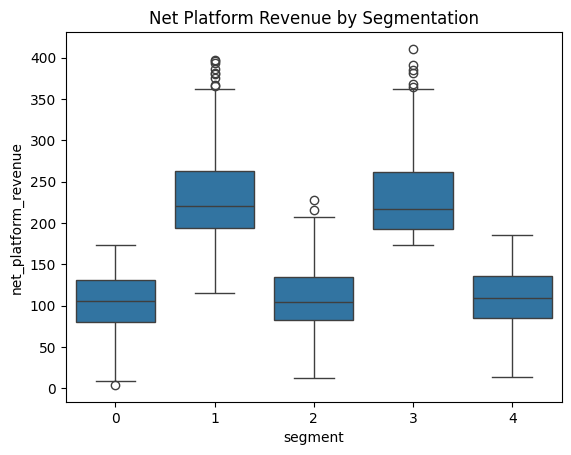

In [46]:
# Graphical segment representation
sns.boxplot(x="segment", y="net_platform_revenue", data=df)
plt.title('Net Platform Revenue by Segmentation')
plt.show()


### Observation of Findings

The boxplot highlights clear revenue stratification across segments:

Segments 1 and 3 show the highest median net platform revenue, with wide upper tails and multiple high-value outliers.

- This confirms these segments as the primary revenue drivers.

- The spread indicates heterogeneity even among high-value users (VIPs vs regular high spenders).

Segments 0, 2, and 4 cluster around lower median revenues with tighter distributions.

- Segment 0 shows the lowest central tendency, reinforcing its low-value, inactive profile.

- Segments 2 and 4 show moderate revenue but lack strong upside.

Overall:
Revenue is not evenly distributed across segments, validating the economic relevance of the segmentation. Retention efforts should prioritize Segments 1 and 3, especially given their differing churn risks.

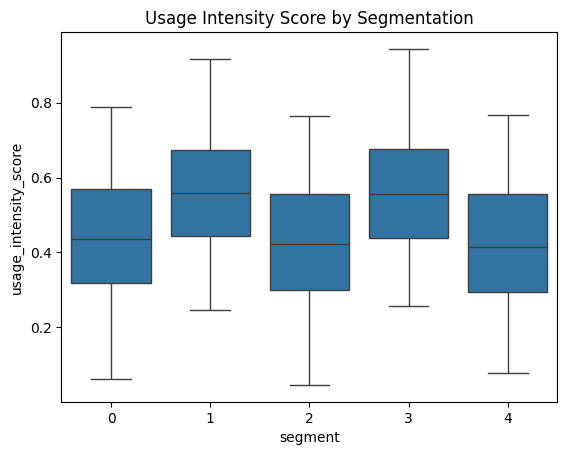

In [47]:
sns.boxplot(x="segment", y="usage_intensity_score", data=df)
plt.title('Usage Intensity Score by Segmentation')
plt.show()

### Observation of Findings

The usage intensity boxplot reveals engagement-driven differentiation:

Segments 1 and 3 again stand out with higher median usage intensity and broader distributions.

- Segment 3’s wide spread suggests historically heavy users who may now be tapering off.

- Segment 1 combines high usage with recency, indicating healthy, ongoing engagement.

Segments 0, 2, and 4 exhibit lower median usage and more compact distributions.

- Segment 0’s lower intensity aligns with inactivity and high churn.

- Segment 4 shows moderate usage sustained by promotions rather than organic engagement.

Overall:
Usage intensity is a strong behavioral differentiator and aligns well with both revenue contribution and churn risk across segments.

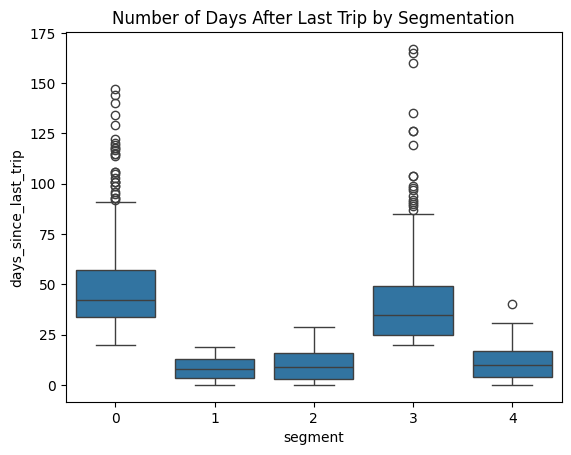

In [48]:
sns.boxplot(x="segment", y="days_since_last_trip", data=df)
plt.title('Number of Days After Last Trip by Segmentation')
plt.show()

### Observation of Findings

Segment 0 - Long-Term Inactive Users

This segment consists of customers who have been inactive for an extended period (median days of ~40–45 since last trip) and are approaching or have already entered churn having Wide upper tail with extreme outliers (> 100 days). The high dispersion suggests varying stages of disengagement.

Segment 1 - Highly Active, Recently Engaged Users

This is a stable, healthy segment with consistent recent activity (Lowest median recency of ~7–8 days), tight distribution with few outliers and minimal signs of disengagement.

Segment 2 - Moderately Active Users

Users remain engaged with low-to-moderate median recency of ~10–12 days, but less consistently than Segment 1. They are not inactive, but engagement could weaken without reinforcement.

Segment 3 - High-Value but Recently Inactive Users

This segment contains historically valuable users who have stopped engaging recently (high median recency ~30–35 days). The outliers (>100 days) indicate customers at very advanced stages of inactivity.

Segment 4 - Promo-Sustained Active Users

Activity is relatively recent with low-to-moderate median recency of ~10–12 days, but less stable than Segment 1, likely sustained through promotional incentives rather than organic demand.

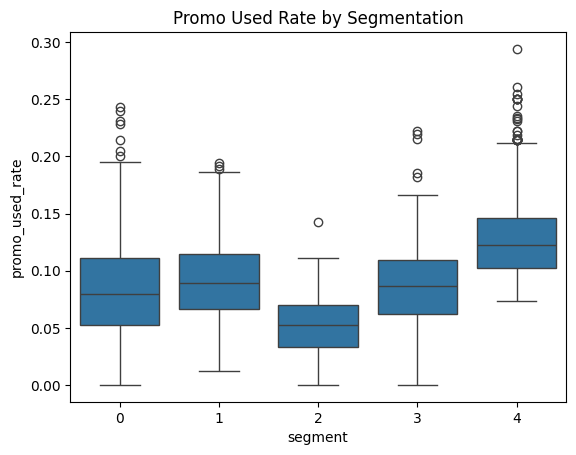

In [49]:
sns.boxplot(x="segment", y="promo_used_rate", data=df)
plt.title('Promo Used Rate by Segmentation')
plt.show()

### Observation of Findings

Segment 4  are highly promo-dependent users with highest median promo usage rate. This segment relies heavily on promotions to remain active. Engagement is sustained primarily through incentives rather than organic demand leading to high risk of margin erosion. Hence, promotions should be carefully targeted and capped in addition to testing non-monetary engagement levers like loyalty perks, UX improvements etc.

Segment 1 are high-value, moderately promo-aware users with moderate promo usage. Promotions are used opportunistically but are not the primary engagement driver. This suggests healthy willingness to pay and strong product fit. Focus should be on loyalty recognition rather than price cuts and avoid over-discounting.

Segment 3 are high-value but promo-sensitive during reactivation showing moderate promo usage with noticeable variability. Promotions likely play a role in attempted reactivation for this high-value but inactive group. Variability suggests mixed responsiveness. Promos should be combined with service recovery messaging with a personalized, time-bound incentives.

Segment 0 are low-value, promo-occasional users with lower median promo usage. Promotions have limited effectiveness for this segment. Low promo usage reflects disengagement rather than price sensitivity. Low-cost, experimental offers should be dopted as promotions alone is unlikely to prevent churn.

Segment 2 are low promo reliance, engagement-driven users with the lowest median promo usage rate. This segment engages with the platform largely without incentives, indicating organic usage behavior and low price sensitivity. Promotions can be used sparingly or not at all and this segment represents strong candidate for engagement nudges.

Promotion dependency clearly differentiates segments:

- Segment 4: Incentive-driven retention

- Segment 1 & 2: Organic engagement

- Segment 3: Conditional promo sensitivity

- Segment 0: Disengaged regardless of promotions

In [50]:
# Save dataset for model
df.to_csv('../data/processed/ridewise_churn_modeling_dataset.csv', index=False)

### Save Segmentation Model for API

In [51]:
# Build segmentation pipeline
X_seg = df[seg_features].copy()

segmentation_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=5, random_state=42, n_init=10))
])

# Fit the pipeline
segmentation_pipeline.fit(X_seg)

# Save segmentation pipeline
os.makedirs("src/models", exist_ok=True)

joblib.dump(
    {
        "segmentation_pipeline": segmentation_pipeline,
        "seg_features": seg_features
    },
    "../src/models/segmentation_model.pkl"
)

['../src/models/segmentation_model.pkl']

In [52]:
segmentation_pipeline.named_steps["scaler"].mean_[:3]


array([  0.46028583,   0.49666667, 138.24137333])

### Summary Analysis

Segmentation was conducted prior to churn modeling to ensure behavioral patterns were learned independently of the churn label.

**Methodology Overview**

**Approach:** Unsupervised learning using K-Means clustering

**Feature set:**
Behavioral and economic indicators including:

- Usage intensity, Engagement recency, Net platform revenue, Promotional usage and dependency, Inactivity flags, Cancellation and cost/burden metrics

**Preprocessing:**

- Removal of identifiers and raw date fields

- Feature scaling using StandardScaler

**Cluster selection:**

- Elbow method indicated diminishing returns beyond K = 5

- Silhouette scores were modest but stable, consistent with real-world behavioral data

- K = 5 selected for optimal balance between structure and interpretability

**Segment Distribution**

The five segments are well-balanced and operationally meaningful:

- Segment sizes range from approximately 10% to 28% of the customer base

- No cluster is excessively small or dominant confirming that the segmentation is structurally sound and actionable

#### Segment-Level Behavioral Insights

**Segment 0: Inactive, Low-Value Users**

- Long inactivity and low usage intensity
- Lowest revenue contribution
- Highest churn rate (~29%)

**Implication:**
- Low ROI for aggressive retention. Best suited for low-cost reactivation or deprioritization.

**Segment 1: High-Value, Active Customers**

- High usage intensity and very recent activity
- Strong revenue contribution
- Low churn rate (~15%)

**Implication:**
- Core customer base. Focus on loyalty, experience, and service quality rather than discounts.

**Segment 2: Low Engagement, Retainable Users**

- Moderate activity with low promo dependence
- Lowest churn rate (~13%)

**Implication:**
- Good candidates for engagement nudges and habit formation initiatives.

**Segment 3: High-Value but Inactive Customers**

- Historically high usage and revenue
- Extended inactivity and elevated churn (~26%)

**Implication:**
- Most strategically critical segment. High-value churn prevention should be prioritized.

**Segment 4: Promo-Dependent Active Users**

- Engagement sustained largely through promotions
- Moderate churn (~14%) but high incentive cost

**Implication:**
- Retention is effective but costly. Promotional strategy should be optimized to protect margins.

**Churn Risk Differentiation by Segment**

Churn is not uniformly distributed across customers:

- Highest churn occurs in inactive segments (0 and 3)

- High-value churn (Segment 3) poses significantly greater revenue risk than volume-based churn

- Segmentation provides essential context beyond raw churn prediction

**Categorical Profiling Validation**

Categorical attributes (signup_channel, income_level, gender, revenue_quartile) were used only for interpretation, not clustering.

**Key observations:**

- Revenue quartile and income level strongly align with high-value segments

- Signup channel and gender distributions are balanced across segments Confirming that segmentation is behavior-driven, not demographically biased

**Visual Validation**

Segment separation was consistently validated across:

- Net platform revenue

- Usage intensity

- Days since last trip

- Promotional usage rate

These visual patterns reinforce the robustness and interpretability of the segmentation.

**Conclusion**

This segmentation analysis successfully identified five distinct and interpretable customer groups that differ meaningfully in engagement, revenue contribution, promotional reliance, inactivity risk, and churn behavior.

The segmentation:

- Enhances understanding of customer heterogeneity

- Enables targeted retention and marketing strategies

- Provides a strong contextual layer to support subsequent churn modeling

This concludes the exploratory and segmentation phase of the project.
The next phase will focus on supervised churn prediction, incorporating segment membership as an explanatory feature.